# Sensitivities

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    grid_search_method,
    sweep_2d,
    contour_plot,
    evaluate
    )

### Initialize the System / Problem

In [3]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [4]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

In [5]:
optimals = np.load("optimals_iteration2.npy")
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.9738227146814404
Optimal delta_v: 3.0242382271468142
Optimal delta_v_angle: 0.0696875
Optimal tof: 0.72910225921522


In [17]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: 1.4475163527313123e-06
Objective value: 3.3315442279843444
Constraint Value in km: 0.5564252859899165
Objective Value in km/s: 3.413264899595321


In [6]:
theta_delta = 0.001

delta_v_delta = 0.002

delta_v_angle_delta = 0.0001

tof_delta = 0.0001

## Theta v Delta_v

In [8]:
theta_delta_v_sweep = Path("theta_delta_v_sweep.npy")

if theta_delta_v_sweep.exists():
    print("Loading existing sweep results...")
    theta_delta_v_sweep = np.load(theta_delta_v_sweep)
    theta_delta_v_sweep = pd.DataFrame(theta_delta_v_sweep, columns=['theta', 'delta_v', 'delta_v_angle', 'tof','total_delta_v','distance_to_llo'])
else:
    print("Performing new sweep...")
    theta_delta_v_sweep = sweep_2d(em, 'theta', theta_delta, 'delta_v', delta_v_delta, 201, optimals, leo_alt_m, lmo_alt_m)
    np.save("theta_delta_v_sweep.npy", theta_delta_v_sweep.to_numpy())
print(theta_delta_v_sweep)

Loading existing sweep results...
          theta   delta_v  delta_v_angle       tof  total_delta_v  \
0      3.972873  3.024318       0.069687  0.729102       3.050044   
1      3.972863  3.024318       0.069687  0.729102       3.052159   
2      3.973503  3.024318       0.069687  0.729102       3.200993   
3      3.973513  3.024318       0.069687  0.729102       3.203642   
4      3.973633  3.024298       0.069687  0.729102       3.246868   
...         ...       ...            ...       ...            ...   
40396  3.974823  3.026158       0.069687  0.729102            NaN   
40397  3.974823  3.026178       0.069687  0.729102            NaN   
40398  3.974823  3.026198       0.069687  0.729102            NaN   
40399  3.974823  3.026218       0.069687  0.729102            NaN   
40400  3.974823  3.026238       0.069687  0.729102            NaN   

       distance_to_llo  
0        -9.057634e-07  
1         2.052742e-06  
2        -4.176657e-07  
3         2.484958e-06  
4         9.

In [22]:
theta = theta_delta_v_sweep['theta'].values
delta_v = theta_delta_v_sweep['delta_v'].values
total_delta_v = theta_delta_v_sweep['total_delta_v'].values

In [21]:
min_row = theta_delta_v_sweep.loc[theta_delta_v_sweep['total_delta_v'].idxmin()].values
print(min_row[4])
print(min_row[5])

3.0500438052413203
-9.057634438773901e-07


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto')


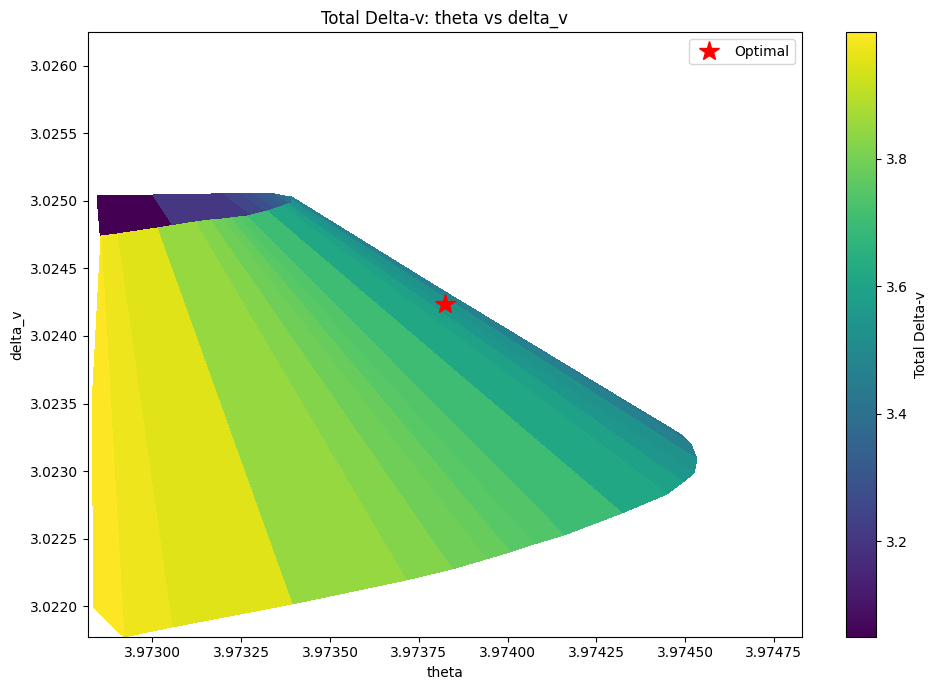

In [23]:
contour_plot(theta_delta_v_sweep, 'theta', 'delta_v', 201, optimals)

## Theta v Alpha

In [ ]:
theta_alpha_sweep = Path("theta_alpha_sweep.npy")

if theta_alpha_sweep.exists():
    print("Loading existing sweep results...")
    theta_alpha_sweep = np.load(theta_alpha_sweep)
    theta_alpha_sweep = pd.DataFrame(theta_alpha_sweep, columns=['theta', 'delta_v', 'delta_v_angle', 'tof','total_delta_v','distance_to_llo'])
else:
    print("Performing new sweep...")
    theta_alpha_sweep = sweep_2d(em, 'theta', theta_delta, 'delta_v_angle', delta_v_angle_delta, 201, optimals, leo_alt_m, lmo_alt_m)
    np.save("theta_alpha_sweep.npy", theta_alpha_sweep.to_numpy())
print(theta_alpha_sweep)

Performing new sweep...
Performing grid search with 201 x 1 x 201 x 1 = 40401 grid points...


In [ ]:
theta_2 = theta_alpha_sweep['theta'].values
delta_v_angle_delta = theta_alpha_sweep['delta_v_angle'].values
total_delta_v = theta_alpha_sweep['total_delta_v'].values

In [ ]:
min_row_2 = theta_alpha_sweep.loc[theta_alpha_sweep['total_delta_v'].idxmin()].values
print(min_row_2[4])
print(min_row_2[5])

3.0500438052413203
-9.057634438773901e-07


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto')


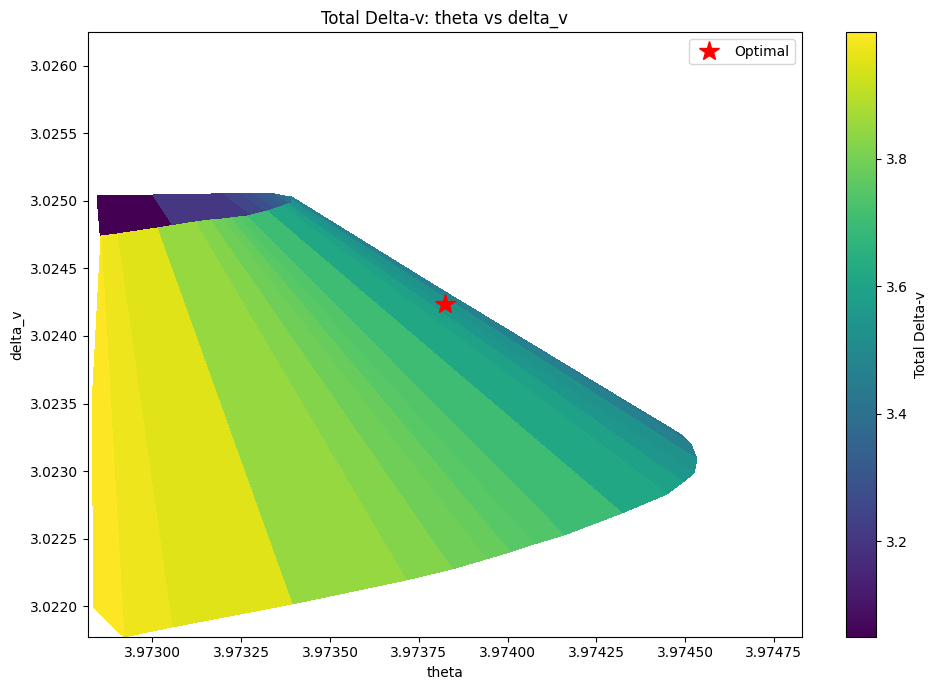

In [ ]:
contour_plot(theta_alpha_sweep, 'theta', 'delta_v_angle', 201, optimals)

## Theta v ToF

In [ ]:
theta_ToF_sweep = Path("theta_ToF_sweep.npy")

if theta_ToF_sweep.exists():
    print("Loading existing sweep results...")
    theta_ToF_sweep = np.load(theta_ToF_sweep)
    theta_ToF_sweep = pd.DataFrame(theta_ToF_sweep, columns=['theta', 'delta_v', 'delta_v_angle', 'tof','total_delta_v','distance_to_llo'])
else:
    print("Performing new sweep...")
    theta_ToF_sweep = sweep_2d(em, 'theta', theta_delta, 'tof', tof_delta, 201, optimals, leo_alt_m, lmo_alt_m)
    np.save("theta_ToF_sweep.npy", theta_ToF_sweep.to_numpy())
print(theta_ToF_sweep)

Performing new sweep...
Performing grid search with 201 x 1 x 201 x 1 = 40401 grid points...


In [ ]:
theta_3 = theta_ToF_sweep['theta'].values
tof = theta_ToF_sweep['tof'].values
total_delta_v = theta_ToF_sweep['total_delta_v'].values

In [ ]:
min_row_3 = theta_ToF_sweep.loc[theta_ToF_sweep['total_delta_v'].idxmin()].values
print(min_row_3[4])
print(min_row_3[5])

3.0500438052413203
-9.057634438773901e-07


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto')


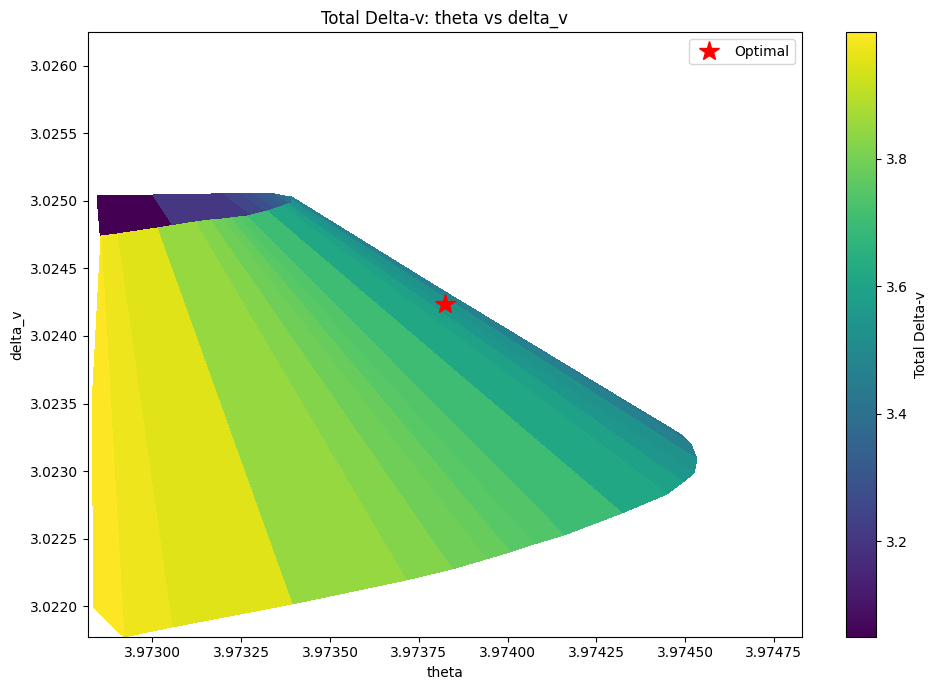

In [ ]:
contour_plot(theta_ToF_sweep, 'theta', 'tof', 201, optimals)

## Delta_v v Alpha

## Delta_v v ToF

## Alpha v ToF